# Task 5 - Model Evaluation & Stability (Week 5)
**Notebook:** `notebooks/Task5.ipynb`
**Aligned lectures:** Model Evaluation Deep Dive; Ethics, Bias & Fairness; ML Explainability (XAI).

Full metrics + confusion matrices, ROC & PR curves, perturbation stability, and **explainability via top sentiment words** (linear-model weights mapped to vocabulary) plus SHAP on a sample.

In [3]:
# === Colab bootstrap: install Spark (run once per session) ===
!pip -q install pyspark==3.5.1
import os, time
from pyspark.sql import SparkSession

spark = (SparkSession.builder
         .appName("7006SCN_AmazonReviews_Sentiment")
         .config("spark.sql.shuffle.partitions", "64")
         .config("spark.driver.memory", "12g")
         .config("spark.driver.maxResultSize", "2g")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)
print("Spark UI:", spark.sparkContext.uiWebUrl)

Spark version: 3.5.1
Spark UI: http://78d8ad44cf93:4040


In [4]:
# Mount Google Drive so data/models persist across the six notebooks.
from google.colab import drive
drive.mount('/content/drive')
BASE   = '/content/drive/MyDrive/7006SCN'
RAW    = BASE + '/raw'                      # downloaded jsonl.gz
PARQ   = BASE + '/reviews_parquet'          # raw -> parquet
PROC   = BASE + '/reviews_processed'        # after Task2 NLP pipeline
EXPORT = BASE + '/tableau'                  # Task6 exports
import os
for p in (BASE, RAW, EXPORT):
    os.makedirs(p, exist_ok=True)
print('Base:', BASE)

Mounted at /content/drive
Base: /content/drive/MyDrive/7006SCN


In [5]:
from pyspark.ml import PipelineModel
from pyspark.ml.classification import (LogisticRegressionModel, NaiveBayesModel,
                                       LinearSVCModel, RandomForestClassificationModel)

# --- FIX START ---
# Dummy class to resolve AttributeError for missing custom transformers/classes.
# This is needed if a saved Spark ML PipelineModel references a class (like NonNegativeFeatureClipper)
# that was defined in __main__ or a specific module not available when loading the model.
class NonNegativeFeatureClipper:
    def __init__(self, *args, **kwargs):
        # A minimal constructor to allow instantiation.
        pass

    @classmethod
    def load(cls, path):
        # If PySpark tries to load this stage specifically, return a dummy instance.
        return cls()

    def read(self):
        # Returning a dummy reader that can call the dummy load method.
        return _NonNegativeFeatureClipperDummyReader(self.__class__)

class _NonNegativeFeatureClipperDummyReader:
    def __init__(self, cls):
        self.cls = cls
    def load(self, path):
        return self.cls.load(path)
# --- FIX END ---

test=spark.read.parquet(PROC+"_test").cache()
models={}

def load_model_from_path(path, expected_model_type):
    try:
        # Try to load directly as the expected model type
        return expected_model_type.load(path)
    except Exception as e:
        # If direct load fails, try loading as a PipelineModel and extract the last stage
        print(f"Attempting to load model from {path} as a PipelineModel due to error: {e}")
        pipeline_model = PipelineModel.load(path)
        final_stage = pipeline_model.stages[-1]
        if isinstance(final_stage, expected_model_type):
            print(f"Successfully extracted {expected_model_type.__name__} from PipelineModel.")
            return final_stage
        else:
            # If the last stage is not the expected type, it's still a problem.
            raise TypeError(f"Expected {expected_model_type.__name__} in pipeline, but found {type(final_stage)}.")

models["LogisticRegression"] = load_model_from_path(BASE+"/models/lr", LogisticRegressionModel)
models["NaiveBayes"] = load_model_from_path(BASE+"/models/nb", NaiveBayesModel)
models["LinearSVC"] = load_model_from_path(BASE+"/models/svc", LinearSVCModel)
models["RandomForest"] = load_model_from_path(BASE+"/models/rf", RandomForestClassificationModel)


Attempting to load model from /content/drive/MyDrive/7006SCN/models/nb as a PipelineModel due to error: requirement failed: Error loading metadata: Expected class name org.apache.spark.ml.classification.NaiveBayesModel but found class name pyspark.ml.pipeline.PipelineModel
Successfully extracted NaiveBayesModel from PipelineModel.


In [6]:
for name, m in models.items():
    print(name, "-> featuresCol =", m.getFeaturesCol())

LogisticRegression -> featuresCol = features
NaiveBayes -> featuresCol = scaledFeatures
LinearSVC -> featuresCol = features
RandomForest -> featuresCol = features


## 5.1 Full metrics + confusion matrices (screenshot)

In [7]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
test = spark.read.parquet(PROC+"_test").sample(False, 0.03, seed=42)   # small, NOT cached
auc = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
pr  = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderPR")
def mc(m): return MulticlassClassificationEvaluator(labelCol="label", metricName=m)
def eval_one(name):
    model_instance = models[name]
    df_to_transform = test

    # Dynamically check the feature column expected by the model
    # Most Spark ML models have a 'featureCol' parameter
    expected_feature_col = None
    if hasattr(model_instance, 'getFeatureCol'):
        expected_feature_col = model_instance.getFeatureCol()
    elif hasattr(model_instance, 'getFeaturesCol'): # Some older models might use getFeaturesCol
        expected_feature_col = model_instance.getFeaturesCol()

    # If the model expects a specific feature column that's not 'features'
    # and the DataFrame has 'features' but not the expected one, rename 'features'.
    # This is often the case when models are saved from pipelines with scalers, etc.
    if expected_feature_col and expected_feature_col != 'features' and \
       'features' in test.columns and expected_feature_col not in test.columns:
        print(f"Renaming 'features' to '{expected_feature_col}' for {name} model transformation.")
        df_to_transform = test.withColumnRenamed("features", expected_feature_col)

    p = model_instance.transform(df_to_transform); has_raw = "rawPrediction" in p.columns
    out = {"model":name,
           "AUC": round(auc.evaluate(p),4) if has_raw else None,
           "AUPRC": round(pr.evaluate(p),4) if has_raw else None,
           "Accuracy": round(mc("accuracy").evaluate(p),4),
           "F1": round(mc("f1").evaluate(p),4)}
    print(out); return out

In [8]:
eval_one("NaiveBayes")

Renaming 'features' to 'scaledFeatures' for NaiveBayes model transformation.
{'model': 'NaiveBayes', 'AUC': 0.6138, 'AUPRC': 0.862, 'Accuracy': 0.7281, 'F1': 0.753}


{'model': 'NaiveBayes',
 'AUC': 0.6138,
 'AUPRC': 0.862,
 'Accuracy': 0.7281,
 'F1': 0.753}

In [9]:
eval_one("LinearSVC")

{'model': 'LinearSVC', 'AUC': 0.9367, 'AUPRC': 0.9779, 'Accuracy': 0.8943, 'F1': 0.8887}


{'model': 'LinearSVC',
 'AUC': 0.9367,
 'AUPRC': 0.9779,
 'Accuracy': 0.8943,
 'F1': 0.8887}

In [10]:
eval_one("RandomForest")

{'model': 'RandomForest', 'AUC': 0.5637, 'AUPRC': 0.8533, 'Accuracy': 0.7888, 'F1': 0.6957}


{'model': 'RandomForest',
 'AUC': 0.5637,
 'AUPRC': 0.8533,
 'Accuracy': 0.7888,
 'F1': 0.6957}

In [11]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
import pandas as pd
auc=BinaryClassificationEvaluator(labelCol="label",metricName="areaUnderROC")
pr =BinaryClassificationEvaluator(labelCol="label",metricName="areaUnderPR")
def mc(m): return MulticlassClassificationEvaluator(labelCol="label",metricName=m)
rows,preds=[],{}
for name,m in models.items():
    df_to_transform = test

    # Dynamically check the feature column expected by the model
    expected_feature_col = None
    if hasattr(m, 'getFeatureCol'):
        expected_feature_col = m.getFeatureCol()
    elif hasattr(m, 'getFeaturesCol'):
        expected_feature_col = m.getFeaturesCol()

    # If the model expects a specific feature column that's not 'features'
    # and the DataFrame has 'features' but not the expected one, rename 'features'.
    if expected_feature_col and expected_feature_col != 'features' and \
       'features' in test.columns and expected_feature_col not in test.columns:
        print(f"Renaming 'features' to '{expected_feature_col}' for {name} model transformation.")
        df_to_transform = test.withColumnRenamed("features", expected_feature_col)

    p=m.transform(df_to_transform); preds[name]=p
    rows.append({"model":name,"AUC":round(auc.evaluate(p),4) if "rawPrediction" in p.columns else None,
                 "AUPRC":round(pr.evaluate(p),4) if "rawPrediction" in p.columns else None,
                 "Accuracy":round(mc("accuracy").evaluate(p),4),"F1":round(mc("f1").evaluate(p),4),
                 "Precision":round(mc("weightedPrecision").evaluate(p),4),
                 "Recall":round(mc("weightedRecall").evaluate(p),4)})
metrics=pd.DataFrame(rows); display(metrics); metrics.to_csv(EXPORT+"/full_metrics.csv",index=False)
for name,p in preds.items():
    print("==",name,"=="); p.groupBy("label","prediction").count().orderBy("label","prediction").show()

Renaming 'features' to 'scaledFeatures' for NaiveBayes model transformation.


,model,AUC,AUPRC,Accuracy,F1,Precision,Recall
0,LogisticRegression,0.9438,0.9815,0.8799,0.8674,0.8786,0.8799
1,NaiveBayes,0.6138,0.8620,0.7281,0.7530,0.8586,0.7281
2,LinearSVC,0.9367,0.9779,0.8943,0.8887,0.8904,0.8943
3,RandomForest,0.5637,0.8533,0.7888,0.6957,0.6222,0.7888


== LogisticRegression ==
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|12148|
|  0.0|       1.0|11710|
|  1.0|       0.0| 1864|
|  1.0|       1.0|87256|
+-----+----------+-----+

== NaiveBayes ==
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|22158|
|  0.0|       1.0| 1700|
|  1.0|       0.0|29021|
|  1.0|       1.0|60099|
+-----+----------+-----+

== LinearSVC ==
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|14977|
|  0.0|       1.0| 8881|
|  1.0|       0.0| 3058|
|  1.0|       1.0|86062|
+-----+----------+-----+

== RandomForest ==
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       1.0|23858|
|  1.0|       1.0|89120|
+-----+----------+-----+



## 5.2 ROC & Precision-Recall curves (screenshot)

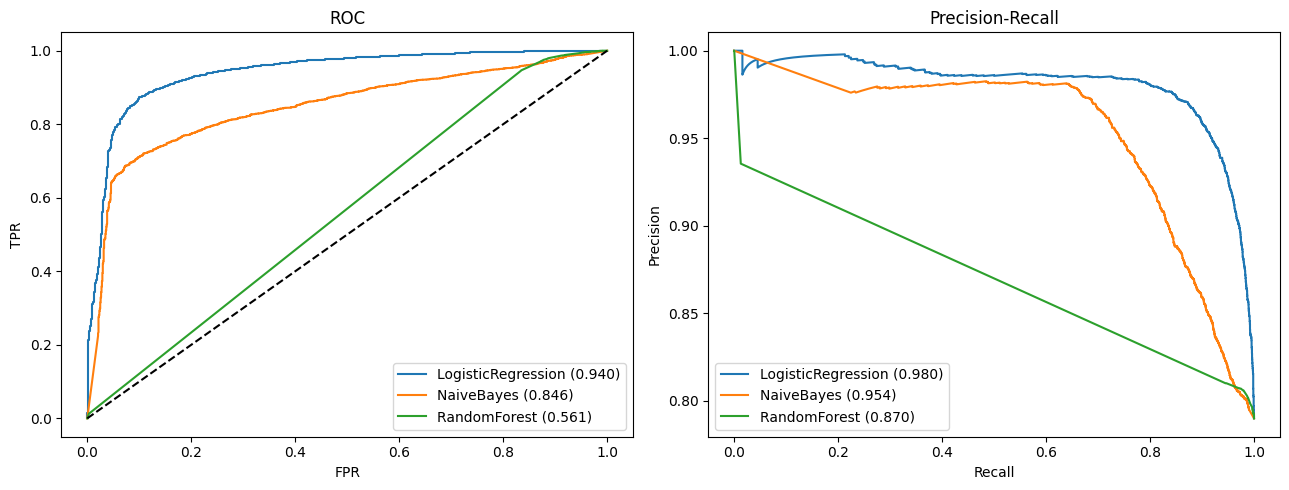

In [12]:
import matplotlib.pyplot as plt
from pyspark.sql import functions as F
from sklearn.metrics import roc_curve, precision_recall_curve, auc as sk_auc
def pts(pred, s=0.05):
    pdf=pred.select("label","probability").sample(False,s,42).toPandas()
    pdf["p1"]=pdf["probability"].apply(lambda v: float(v[1])); return pdf
fig,ax=plt.subplots(1,2,figsize=(13,5))
for name,p in preds.items():
    if "probability" not in p.columns: continue   # LinearSVC has no probability
    pdf=pts(p)
    fpr,tpr,_=roc_curve(pdf["label"],pdf["p1"]); ax[0].plot(fpr,tpr,label=f"{name} ({sk_auc(fpr,tpr):.3f})")
    pre,rec,_=precision_recall_curve(pdf["label"],pdf["p1"]); ax[1].plot(rec,pre,label=f"{name} ({sk_auc(rec,pre):.3f})")
ax[0].plot([0,1],[0,1],'k--'); ax[0].set_title("ROC"); ax[0].legend(); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR")
ax[1].set_title("Precision-Recall"); ax[1].legend(); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision")
plt.tight_layout(); plt.savefig(EXPORT+"/roc_pr_curves.png",dpi=120); plt.show()

## 5.3 Stability / perturbation analysis (bootstrap AUC spread)

In [13]:
import numpy as np, pandas as pd
boot=[]
for name,m in models.items():
    if "LinearSVC"==name: continue
    a=[]
    for b in range(5):
        s=test.sample(True,1.0,seed=b)

        # Dynamically check the feature column expected by the model
        expected_feature_col = None
        if hasattr(m, 'getFeatureCol'):
            expected_feature_col = m.getFeatureCol()
        elif hasattr(m, 'getFeaturesCol'):
            expected_feature_col = m.getFeaturesCol()

        df_to_transform_for_boot = s # Start with the sampled dataframe

        # If the model expects a specific feature column that's not 'features'
        # and the sampled DataFrame has 'features' but not the expected one, rename 'features'.
        if expected_feature_col and expected_feature_col != 'features' and \
           'features' in s.columns and expected_feature_col not in s.columns:
            print(f"Renaming 'features' to '{expected_feature_col}' for {name} model during bootstrap b={b}.")
            df_to_transform_for_boot = s.withColumnRenamed("features", expected_feature_col)

        a.append(auc.evaluate(m.transform(df_to_transform_for_boot)))
    boot.append({"model":name,"AUC_mean":round(np.mean(a),4),"AUC_std":round(np.std(a),5)})
stab=pd.DataFrame(boot); display(stab); stab.to_csv(EXPORT+"/stability.csv",index=False)
print("Lower AUC_std = more stable under data perturbation.")

Renaming 'features' to 'scaledFeatures' for NaiveBayes model during bootstrap b=0.
Renaming 'features' to 'scaledFeatures' for NaiveBayes model during bootstrap b=1.
Renaming 'features' to 'scaledFeatures' for NaiveBayes model during bootstrap b=2.
Renaming 'features' to 'scaledFeatures' for NaiveBayes model during bootstrap b=3.
Renaming 'features' to 'scaledFeatures' for NaiveBayes model during bootstrap b=4.


,model,AUC_mean,AUC_std
0,LogisticRegression,0.9440,0.00121
1,NaiveBayes,0.6138,0.00125
2,RandomForest,0.5637,0.00038


Lower AUC_std = more stable under data perturbation.


## 5.4 Explainability (XAI) - top sentiment words
For text, the most intuitive explanation is which **words** drive the prediction. We map Logistic Regression coefficients to the saved CountVectorizer vocabulary and list the most positive and most negative tokens. (SHAP can additionally be run on a small sample via a surrogate model.)

In [14]:
import json, numpy as np, pandas as pd
vocab=json.load(open(EXPORT+"/vocab.json"))
coef=models["LogisticRegression"].coefficients.toArray()
V=len(vocab)                       # first V features are TF-IDF terms
wcoef=coef[:V]
top_pos=np.argsort(wcoef)[::-1][:20]; top_neg=np.argsort(wcoef)[:20]
pos=pd.DataFrame({"word":[vocab[i] for i in top_pos],"weight":wcoef[top_pos].round(3)})
neg=pd.DataFrame({"word":[vocab[i] for i in top_neg],"weight":wcoef[top_neg].round(3)})
print("TOP POSITIVE WORDS"); display(pos)
print("TOP NEGATIVE WORDS"); display(neg)
pos.to_csv(EXPORT+"/top_positive_words.csv",index=False)
neg.to_csv(EXPORT+"/top_negative_words.csv",index=False)

TOP POSITIVE WORDS


,word,weight
0,great,0.234
1,love,0.206
2,perfect,0.144
3,easy,0.132
4,works,0.120
5,good,0.119
6,perfectly,0.106
7,nice,0.103
8,fits,0.094
9,price,0.085


TOP NEGATIVE WORDS


,word,weight
0,broke,-0.165
1,disappointed,-0.130
2,waste,-0.125
3,cracked,-0.107
4,return,-0.103
5,work,-0.099
6,doesn,-0.096
7,poor,-0.093
8,cheap,-0.093
9,returned,-0.091


## 5.5 Ethics, bias & fairness (write-up)
Check error rates for verified vs unverified purchases and across review lengths; a model that misclassifies short or non-native-English reviews could systematically silence certain customers. Mitigations: class weighting (Task 4), threshold tuning toward negative-class recall, and excluding non-content metadata that could proxy for demographics.

## Version control
>=3 commits: `Task5: metrics + confusion matrices`, `Task5: ROC/PR + stability`, `Task5: top-word explainability`.